In [1]:
# ============================================================
# 04_mouse_scoring.ipynb
# Mouse Dynamics — Pairwise Biometric Scorer
# ============================================================

"""
Goal:
  - Load mouse session embeddings (CLS) + user/session metadata
  - Build pairwise dataset:
      * Positive pairs: same user (genuine)
      * Negative pairs: different users (impostor)
  - Train a logistic regression scorer on concatenated embeddings
  - Evaluate:
      * ROC-AUC
      * EER
      * FRR @ FAR = 1%
  - Save:
      * models/mouse_pair_scorer.joblib
      * models/mouse_thresholds.npz
      * mouse_roc_curve.png
"""

# ============================================================
# Setup
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import joblib
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
EMB_DIR = Path("embeddings")
MODEL_DIR = Path("models")
FIG_DIR = Path("figures")

MODEL_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

In [2]:
# ============================================================
# 1. Load embeddings + metadata
# ============================================================

EMB_CLS_PATH = EMB_DIR / "mouse_embeddings_cls.npy"
FEATURES_PATH = DATA_DIR / "mouse_features.npz"

Z = np.load(EMB_CLS_PATH)  # shape: (N_sessions, 32)
data = np.load(FEATURES_PATH, allow_pickle=True)

user_ids = data["user_id"].astype(int)
session_ids = data["session_id"]

N, D = Z.shape
unique_users = np.unique(user_ids)

print("Embeddings shape:", Z.shape)
print("Unique users:", unique_users.shape[0])
print("Sessions per user:")
print(pd.Series(user_ids).value_counts().sort_index())

Embeddings shape: (1676, 32)
Unique users: 10
Sessions per user:
7     158
9     130
12    240
15    253
16    201
20    114
21    121
23    142
29    124
35    193
Name: count, dtype: int64


In [3]:
# ============================================================
# 2. Build pairwise dataset
# ============================================================

def build_pairs(Z, user_ids, max_pairs_per_user=3000):
    """
    Build a balanced pairwise dataset:
      - X_pairs: concatenated embeddings (z_i || z_j)
      - y_pairs: 1 for same-user, 0 for impostor
    """

    rng = np.random.default_rng(SEED)

    X_pairs = []
    y_pairs = []

    unique_users = np.unique(user_ids)

    for u in unique_users:
        idx_u = np.where(user_ids == u)[0]
        n_u = len(idx_u)

        if n_u < 2:
            continue

        # -------- Positive pairs (same user) --------
        # all combinations would be n_u*(n_u-1)/2; we subsample
        possible_pos = []
        for i in range(n_u):
            for j in range(i + 1, n_u):
                possible_pos.append((idx_u[i], idx_u[j]))

        if len(possible_pos) > max_pairs_per_user:
            pos_pairs = rng.choice(
                possible_pos,
                size=max_pairs_per_user,
                replace=False
            )
        else:
            pos_pairs = possible_pos

        for i, j in pos_pairs:
            X_pairs.append(np.concatenate([Z[i], Z[j]]))
            y_pairs.append(1)

        # -------- Negative pairs (impostor) --------
        # sample other-user indices
        idx_not_u = np.where(user_ids != u)[0]
        # we aim for ~same number of negatives as positives
        n_neg_target = len(pos_pairs)

        if n_neg_target > 0:
            neg_i = rng.choice(idx_u, size=n_neg_target, replace=True)
            neg_j = rng.choice(idx_not_u, size=n_neg_target, replace=True)

            for i2, j2 in zip(neg_i, neg_j):
                X_pairs.append(np.concatenate([Z[i2], Z[j2]]))
                y_pairs.append(0)

    X_pairs = np.array(X_pairs, dtype=np.float32)
    y_pairs = np.array(y_pairs, dtype=np.int64)

    print("Pair dataset:")
    print("  X_pairs:", X_pairs.shape)
    print("  positives:", int(y_pairs.sum()))
    print("  negatives:", int((y_pairs == 0).sum()))

    return X_pairs, y_pairs

X_pairs, y_pairs = build_pairs(Z, user_ids, max_pairs_per_user=2000)

Pair dataset:
  X_pairs: (40000, 64)
  positives: 20000
  negatives: 20000


In [4]:
# ============================================================
# 3. Train/val split for pairs
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_pairs, y_pairs,
    test_size=0.2,
    random_state=SEED,
    stratify=y_pairs,
)

print("Train pairs:", X_train.shape, "Val pairs:", X_val.shape)

Train pairs: (32000, 64) Val pairs: (8000, 64)


In [5]:
# ============================================================
# 4. Train logistic regression scorer
# ============================================================

scorer = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1,
)

print("\n🔧 Training logistic regression scorer...")
scorer.fit(X_train, y_train)

# Predict probabilities for validation set (prob of "same user")
val_scores = scorer.predict_proba(X_val)[:, 1]
roc_auc = roc_auc_score(y_val, val_scores)

print(f"ROC-AUC (pairwise scorer): {roc_auc:.4f}")


🔧 Training logistic regression scorer...
ROC-AUC (pairwise scorer): 0.5385


In [6]:
# ============================================================
# 5. EER + FRR@FAR=1%
# ============================================================

fpr, tpr, thresholds = roc_curve(y_val, val_scores)

# FNR = 1 - TPR
fnr = 1 - tpr

# EER is the point where FPR ~ FNR
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
eer_threshold = thresholds[eer_idx]

# FAR = FPR; FRR = FNR
# We want FRR when FAR ~ 1%
# Find smallest threshold where FPR <= 0.01
far_target = 0.01
# indices where FPR <= 0.01
idx_far1 = np.where(fpr <= far_target)[0]
if len(idx_far1) == 0:
    # No such point; fall back to closest
    idx_far1 = [np.argmin(np.abs(fpr - far_target))]
idx_far1 = idx_far1[-1]  # highest threshold with FPR <= 1%

far_achieved = fpr[idx_far1]
frr_at_far1 = fnr[idx_far1]
far1_threshold = thresholds[idx_far1]

print(f"\n==== Mouse Pairwise Scoring Results ====")
print(f"ROC-AUC         : {roc_auc:.4f}")
print(f"EER             : {eer*100:.2f}%  @ threshold={eer_threshold:.4f}")
print(f"FRR @ FAR=1%    : {frr_at_far1*100:.2f}%  (achieved FAR={far_achieved*100:.2f}%)  @ threshold={far1_threshold:.4f}")


==== Mouse Pairwise Scoring Results ====
ROC-AUC         : 0.5385
EER             : 47.40%  @ threshold=0.4977
FRR @ FAR=1%    : 98.50%  (achieved FAR=1.00%)  @ threshold=0.5971


In [7]:
# ============================================================
# 6. Save scorer + thresholds
# ============================================================

SCORER_PATH = MODEL_DIR / "mouse_pair_scorer.joblib"
THR_PATH    = MODEL_DIR / "mouse_thresholds.npz"

joblib.dump(scorer, SCORER_PATH)
np.savez(
    THR_PATH,
    eer_threshold=eer_threshold,
    far1_threshold=far1_threshold,
    roc_auc=roc_auc,
    eer=eer,
    frr_at_far1=frr_at_far1,
    far_achieved=far_achieved,
)

print("\n💾 Saved pairwise scorer →", SCORER_PATH)
print("💾 Saved thresholds      →", THR_PATH)


💾 Saved pairwise scorer → models/mouse_pair_scorer.joblib
💾 Saved thresholds      → models/mouse_thresholds.npz


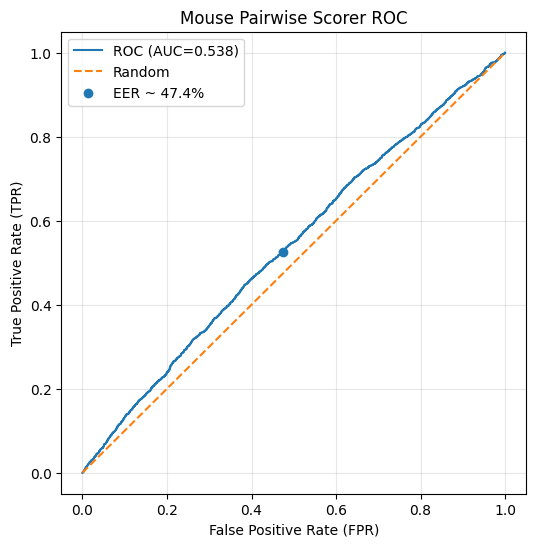

💾 Saved ROC figure → figures/mouse_roc_curve.png


In [8]:
# ============================================================
# 7. Plot ROC curve
# ============================================================

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.scatter(fpr[eer_idx], tpr[eer_idx], marker="o", label=f"EER ~ {eer*100:.1f}%")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Mouse Pairwise Scorer ROC")
plt.legend()
plt.grid(True, alpha=0.3)

FIG_PATH = FIG_DIR / "mouse_roc_curve.png"
plt.savefig(FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("💾 Saved ROC figure →", FIG_PATH)

In [9]:
# ============================================================
# 8. Summary
# ============================================================

print("\n===== Mouse Pairwise Scorer Summary =====")
print(f"Embeddings      : {Z.shape}")
print(f"Pairs (total)   : {X_pairs.shape[0]}")
print(f"ROC-AUC         : {roc_auc:.4f}")
print(f"EER             : {eer*100:.2f}%  @ thr={eer_threshold:.4f}")
print(f"FRR @ FAR=1%    : {frr_at_far1*100:.2f}% (FAR={far_achieved*100:.2f}%) @ thr={far1_threshold:.4f}")
print("Scorer path     :", SCORER_PATH)
print("Thresholds path :", THR_PATH)


===== Mouse Pairwise Scorer Summary =====
Embeddings      : (1676, 32)
Pairs (total)   : 40000
ROC-AUC         : 0.5385
EER             : 47.40%  @ thr=0.4977
FRR @ FAR=1%    : 98.50% (FAR=1.00%) @ thr=0.5971
Scorer path     : models/mouse_pair_scorer.joblib
Thresholds path : models/mouse_thresholds.npz
